In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import random

from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device.type} device")

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

Using cuda device


In [3]:
# ===============================
# LOAD DATASET (WIKITEXT-2)
# ===============================
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

train_text = dataset["train"]["text"]
test_text  = dataset["test"]["text"]


In [47]:
train_text

Column(['', ' = Valkyria Chronicles III = \n', '', ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game mor

In [13]:
# ===============================
# TOKENIZER (WORD LEVEL)
# ===============================
special_tokens = ["<pad>", "<unk>"]
tokenizer = Tokenizer(
    WordLevel(
        unk_token="<unk>"
    )
)

tokenizer.pre_tokenizer = Whitespace()

trainer = WordLevelTrainer(
    min_frequency=2,
    special_tokens=special_tokens
)

tokenizer.train_from_iterator(train_text, trainer)

# SAFETY CHECKS (DO NOT SKIP)
assert tokenizer.token_to_id("<unk>") is not None, "UNK token missing!"
assert tokenizer.token_to_id("<pad>") is not None, "PAD token missing!"

vocab_size = tokenizer.get_vocab_size() 


In [14]:
# FORCE PAD TOKEN IF MISSING
if tokenizer.token_to_id("<pad>") is None:
    tokenizer.add_special_tokens(["<pad>"])

    
pad_idx = tokenizer.token_to_id("<pad>")
unk_idx = tokenizer.token_to_id("<unk>")

assert pad_idx is not None, "PAD token still missing!"
assert unk_idx is not None, "UNK token still missing!"


In [15]:
# ===============================
# ENCODE TEXT
# ===============================
def encode_text(text_list, tokenizer):
    ids = []
    for line in text_list:
        enc = tokenizer.encode(line)
        ids.extend(enc.ids)
    return torch.tensor(ids, dtype=torch.long)

train_data = encode_text(train_text, tokenizer)
test_data  = encode_text(test_text, tokenizer)

In [24]:
# ===============================
# DATASET CLASS
# ===============================
sequence_length = 35
batch_size = 128

class LanguageModelDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+1:idx+self.seq_length+1]
        return x, y

train_dataset = LanguageModelDataset(train_data, sequence_length)
test_dataset  = LanguageModelDataset(test_data, sequence_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,  pin_memory=True)

In [25]:
# ===============================
# MODEL: LSTM LANGUAGE MODEL
# ===============================
class LSTM_Model(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_size=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        logits = self.fc(out)
        return logits


In [28]:
# ===============================
# TRAIN FUNCTION
# ===============================
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0.0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device , non_blocking = True ), y.to(device , non_blocking = True)

        optimizer.zero_grad()
        logits = model(X)

        loss = loss_fn(
            logits.view(-1, logits.size(-1)),
            y.view(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        if batch == 0:
            current = batch * len(X)
            print(f"loss: {loss.item():.4f} ")

    avg_loss = total_loss / len(dataloader)
    perplexity = math.exp(avg_loss)

    return avg_loss, perplexity

In [29]:
# ===============================
# TEST FUNCTION
# ===============================
def test(dataloader, model, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device , non_blocking = True), y.to(device , non_blocking = True)
            logits = model(X)

            loss = loss_fn(
                logits.view(-1, logits.size(-1)),
                y.view(-1)
            )

            total_loss += loss.item()

    avg_loss = total_loss / num_batches
    perplexity = math.exp(avg_loss)

    print(
        f"Test Metrics:\n"
        f" Perplexity: {perplexity:.2f}\n"
        f" Avg loss: {avg_loss:.4f}"
    )

    return avg_loss, perplexity

In [30]:
# ===============================
# TRAINING LOOP
# ===============================
epochs = 4
lr = 3e-4

model = LSTM_Model(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_idx)

train_losses, train_ppls = [], []
test_losses, test_ppls = [], []

best_ppl = float("inf")

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}\n-------------------------------")

    tr_loss, tr_ppl = train(train_loader, model, loss_fn, optimizer, device)
    te_loss, te_ppl = test(test_loader, model, loss_fn, device)

    train_losses.append(tr_loss)
    train_ppls.append(tr_ppl)
    test_losses.append(te_loss)
    test_ppls.append(te_ppl)

    if te_ppl < best_ppl:
        best_ppl = te_ppl
        torch.save(model.state_dict(), "LSTM_WikiText2.pth")

print("Training Complete")



Epoch 1
-------------------------------
loss: 10.2995 
Test Metrics:
 Perplexity: 172.40
 Avg loss: 5.1498

Epoch 2
-------------------------------
loss: 4.9539 
Test Metrics:
 Perplexity: 152.04
 Avg loss: 5.0241

Epoch 3
-------------------------------
loss: 4.3174 
Test Metrics:
 Perplexity: 163.38
 Avg loss: 5.0961

Epoch 4
-------------------------------
loss: 3.9572 
Test Metrics:
 Perplexity: 181.27
 Avg loss: 5.2000

Epoch 5
-------------------------------
loss: 3.7010 


KeyboardInterrupt: 

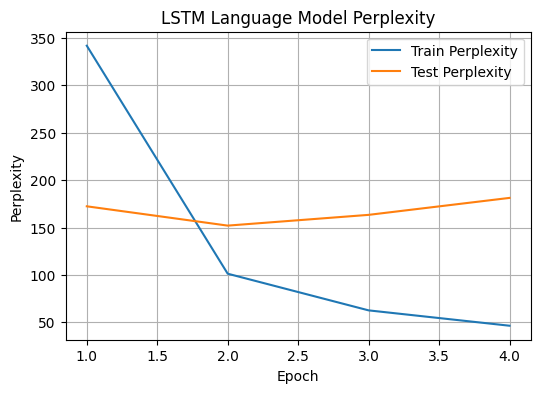

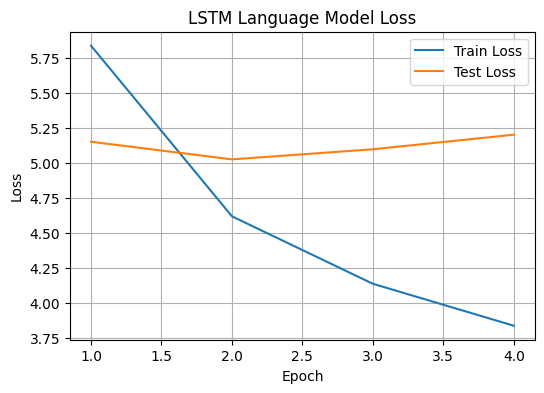

In [32]:
# ===============================
# PLOTTING
# ===============================
from matplotlib import pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_ppls, label="Train Perplexity")
plt.plot(epochs_range, test_ppls, label="Test Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("LSTM Language Model Perplexity")
plt.legend()
plt.grid(True)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Language Model Loss")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
model = LSTM_Model(vocab_size).to(device)
model.load_state_dict(torch.load("LSTM_WikiText2.pth", map_location=device))
model.eval()


LSTM_Model(
  (embedding): Embedding(30000, 256, padding_idx=0)
  (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=30000, bias=True)
)

In [34]:
def sample_from_logits(logits, temperature=1.0):
    logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()


In [35]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=50,
    temperature=1.0,
    device="cuda"
):
    model.eval()

    # Encode prompt
    encoded = tokenizer.encode(prompt)
    input_ids = torch.tensor(encoded.ids, dtype=torch.long).unsqueeze(0).to(device)

    generated = encoded.ids.copy()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(input_ids)

            # Take last time step
            next_token_logits = logits[:, -1, :]

            next_token = sample_from_logits(
                next_token_logits.squeeze(0),
                temperature
            )

            generated.append(next_token)

            # Append token
            input_ids = torch.cat(
                [input_ids, torch.tensor([[next_token]], device=device)],
                dim=1
            )

            # Keep context length manageable
            if input_ids.size(1) > sequence_length:
                input_ids = input_ids[:, -sequence_length:]

    return tokenizer.decode(generated)


In [37]:
prompt = "The meaning of life is"
print(generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=0.8,
    device=device
))


The meaning of life is the sixth paid medieval Christian player and the narrator for the first draft of his life . In his first studio album , EU ) is a sequel in the soundtrack . The episode is inspired by the musicians at the 2003 Australian Summer Olympics . The series ' inclusion of the episode was released to release on August 2 , 2009 , a higher track than the , in which it had sold over $ 5 million for the album . Collection emphasized that " I have a bit about about 1 minutes . " Cresswell said that


In [38]:
class GRU_Model(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_size=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.gru = nn.GRU(
            embed_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)           # (batch, seq_len, embed_dim)
        out, _ = self.gru(x)            # (batch, seq_len, hidden_size)
        logits = self.fc(out)           # (batch, seq_len, vocab_size)
        return logits


In [39]:
# ===============================
# TRAINING LOOP
# ===============================
epochs = 4
lr = 3e-4

model = GRU_Model(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_idx)

train_losses, train_ppls = [], []
test_losses, test_ppls = [], []

best_ppl = float("inf")

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}\n-------------------------------")

    tr_loss, tr_ppl = train(train_loader, model, loss_fn, optimizer, device)
    te_loss, te_ppl = test(test_loader, model, loss_fn, device)

    train_losses.append(tr_loss)
    train_ppls.append(tr_ppl)
    test_losses.append(te_loss)
    test_ppls.append(te_ppl)

    if te_ppl < best_ppl:
        best_ppl = te_ppl
        torch.save(model.state_dict(), "GRU_WikiText2.pth")

print("Training Complete")



Epoch 1
-------------------------------
loss: 10.3010 
Test Metrics:
 Perplexity: 159.60
 Avg loss: 5.0726

Epoch 2
-------------------------------
loss: 4.7833 
Test Metrics:
 Perplexity: 155.82
 Avg loss: 5.0487

Epoch 3
-------------------------------
loss: 4.1692 
Test Metrics:
 Perplexity: 168.34
 Avg loss: 5.1260

Epoch 4
-------------------------------
loss: 3.9209 
Test Metrics:
 Perplexity: 184.11
 Avg loss: 5.2155
Training Complete


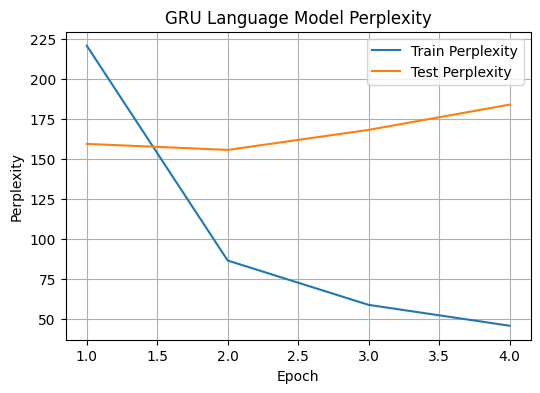

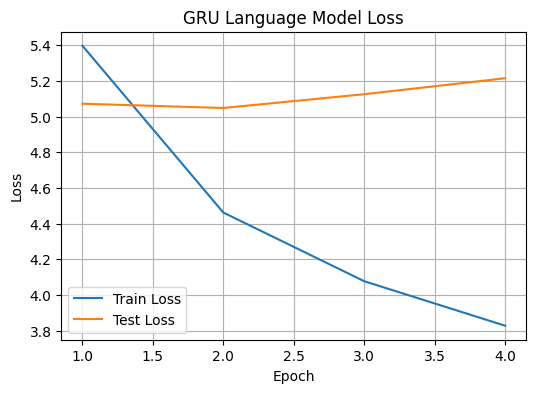

In [46]:
# ===============================
# PLOTTING
# ===============================
from matplotlib import pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_ppls, label="Train Perplexity")
plt.plot(epochs_range, test_ppls, label="Test Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("GRU Language Model Perplexity")
plt.legend()
plt.grid(True)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Language Model Loss")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
model = GRU_Model(vocab_size).to(device)
model.load_state_dict(torch.load("GRU_WikiText2.pth", map_location=device))
model.eval()

GRU_Model(
  (embedding): Embedding(30000, 256, padding_idx=0)
  (gru): GRU(256, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=30000, bias=True)
)

In [42]:
def sample_from_logits(logits, temperature=1.0):
    logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()


In [43]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=50,
    temperature=1.0,
    device="cuda"
):
    model.eval()

    # Encode prompt
    encoded = tokenizer.encode(prompt)
    input_ids = torch.tensor(encoded.ids, dtype=torch.long).unsqueeze(0).to(device)

    generated = encoded.ids.copy()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(input_ids)

            # Take last time step
            next_token_logits = logits[:, -1, :]

            next_token = sample_from_logits(
                next_token_logits.squeeze(0),
                temperature
            )

            generated.append(next_token)

            # Append token
            input_ids = torch.cat(
                [input_ids, torch.tensor([[next_token]], device=device)],
                dim=1
            )

            # Keep context length manageable
            if input_ids.size(1) > sequence_length:
                input_ids = input_ids[:, -sequence_length:]

    return tokenizer.decode(generated)


In [44]:
prompt = "The meaning of life is"
print(generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=0.8,
    device=device
))

The meaning of life is the minds of the symbolic gods , who is proud of this behaviour , may apply as " a discretionary matrix " . When the group will be a " late part for the World " or " Hawaiʻi " , " I will never be in his review of [ sic ] " . Maza said that " The idea " and that " moving down a crescendo up and some " tsak " and " " , which was not a sophomore . He was also liked , but death could be pleased with Stefani "
